In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import load_epoched_bands
from src.models import (
    build_svm, build_lda, build_rf, build_csp_pipeline,
    evaluate_model, save_model,
    save_metrics, run_all_visualizations
)


In [2]:
subjects      = ['A01T', 'A02T', 'A03T', 'A04T', 'A05T', 'A06T', 'A07T', 'A08T', 'A09T']
FEATURES_PATH = '../data/features/'
MODELS_PATH   = '../results/models/baseline/'
METRICS_PATH  = '../results/metrics/baseline/'
FIGURES_PATH  = '../results/figures/training/baseline/'
CLASS_NAMES   = ['Left Hand', 'Right Hand', 'Feet', 'Tongue']

In [3]:
all_results = {}

for subject_id in subjects:
    print(f"\n{'='*50}")
    print(f"  {subject_id}")
    print(f"{'='*50}")

    # Load raw epochs instead of pre-CSPed features
    X, y = load_epoched_bands(subject_id, load_path='../data/processed/')

    models = {
        'SVM': build_csp_pipeline(build_svm()),
        'LDA': build_csp_pipeline(build_lda()),
        'RF':  build_csp_pipeline(build_rf())
    }

    all_results[subject_id] = {}

    for model_name, model in models.items():
        print(f"\n  Training {model_name} (CSP inside CV)...")
        result = evaluate_model(model, X, y)
        print(f"  Accuracy: {result['mean']*100:.1f}% (+/- {result['std']*100:.1f}%)")
        print(f"  Per fold: {np.round(result['scores']*100, 1)}")

        model.fit(X, y)
        save_model(model, subject_id, model_name, save_path=MODELS_PATH)
        all_results[subject_id][model_name] = result

print("\nAll subjects done.")



  A01T
Loaded raw epoched bands for A01T: X=(244, 2, 22, 751), y=(244,)

  Training SVM (CSP inside CV)...
Computing rank from data with rank=None
    Using tolerance 2.3e-05 (2.2e-16 eps * 22 dim * 4.7e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using SHRINKAGE
Done.
Estimating class=1 covariance using SHRINKAGE
Done.
Estimating class=2 covariance using SHRINKAGE
Done.
Estimating class=3 covariance using SHRINKAGE
Done.
Computing rank from data with rank=None
    Using tolerance 2.3e-05 (2.2e-16 eps * 22 dim * 4.8e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using SHRINKAGE
Done.
Estimating class=1 covariance using SHRINKAGE
Done.
Estimating class=2 covariance using SHRINKAGE
Done.
Estimating class=3 covaria

In [4]:
# Save all metrics to CSV files
acc_df, f1_df, fold_df = save_metrics(all_results, subjects, save_path=METRICS_PATH)

Saved accuracy_summary.csv
Saved per_class_metrics.csv
Saved per_fold_scores.csv


In [5]:
# Print accuracy summary table
print("ACCURACY SUMMARY")
print("="*70)
rows = []
for subject_id in subjects:
    row = {'Subject': subject_id}
    for model_name in ['SVM', 'LDA', 'RF']:
        mean = all_results[subject_id][model_name]['mean']
        std  = all_results[subject_id][model_name]['std']
        row[model_name] = f"{mean*100:.1f}% (+/-{std*100:.1f}%)"
    rows.append(row)

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

print()
print("AVERAGE ACROSS ALL SUBJECTS")
print("-"*40)
for model_name in ['SVM', 'LDA', 'RF']:
    avg = np.mean([all_results[s][model_name]['mean'] for s in subjects])
    std = np.std([all_results[s][model_name]['mean'] for s in subjects])
    print(f"  {model_name}: {avg*100:.1f}% (+/- {std*100:.1f}%)")
print(f"  Chance level: 25.0%")

ACCURACY SUMMARY
Subject             SVM             LDA               RF
   A01T 83.2% (+/-5.0%) 81.5% (+/-5.1%)  78.7% (+/-5.3%)
   A02T 54.1% (+/-4.1%) 58.2% (+/-4.8%)  53.7% (+/-4.6%)
   A03T 88.1% (+/-4.9%) 87.3% (+/-4.1%)  86.1% (+/-6.5%)
   A04T 43.4% (+/-7.5%) 46.9% (+/-7.6%) 46.1% (+/-10.2%)
   A05T 40.6% (+/-4.6%) 42.2% (+/-6.7%)  44.2% (+/-5.1%)
   A06T 53.6% (+/-5.2%) 50.0% (+/-2.7%)  51.1% (+/-3.6%)
   A07T 76.2% (+/-3.7%) 81.1% (+/-3.4%)  75.0% (+/-5.1%)
   A08T 84.9% (+/-3.6%) 84.5% (+/-3.8%)  81.4% (+/-2.6%)
   A09T 64.3% (+/-5.3%) 64.3% (+/-4.3%)  63.9% (+/-5.3%)

AVERAGE ACROSS ALL SUBJECTS
----------------------------------------
  SVM: 65.4% (+/- 17.3%)
  LDA: 66.2% (+/- 16.7%)
  RF: 64.5% (+/- 15.3%)
  Chance level: 25.0%


In [6]:
# Best and worst subjects
print("BEST MODEL PER SUBJECT")
print("-"*40)
for subject_id in subjects:
    accs       = {m: all_results[subject_id][m]['mean'] for m in ['SVM', 'LDA', 'RF']}
    best_model = max(accs, key=accs.get)
    worst_model = min(accs, key=accs.get)
    print(f"  {subject_id}: best={best_model} ({accs[best_model]*100:.1f}%)  worst={worst_model} ({accs[worst_model]*100:.1f}%)")

print()
best_overall  = max(subjects, key=lambda s: all_results[s]['SVM']['mean'])
worst_overall = min(subjects, key=lambda s: all_results[s]['SVM']['mean'])
print(f"Best overall subject (SVM):  {best_overall} — {all_results[best_overall]['SVM']['mean']*100:.1f}%")
print(f"Worst overall subject (SVM): {worst_overall} — {all_results[worst_overall]['SVM']['mean']*100:.1f}%")

BEST MODEL PER SUBJECT
----------------------------------------
  A01T: best=SVM (83.2%)  worst=RF (78.7%)
  A02T: best=LDA (58.2%)  worst=RF (53.7%)
  A03T: best=SVM (88.1%)  worst=RF (86.1%)
  A04T: best=LDA (46.9%)  worst=SVM (43.4%)
  A05T: best=RF (44.2%)  worst=SVM (40.6%)
  A06T: best=SVM (53.6%)  worst=LDA (50.0%)
  A07T: best=LDA (81.1%)  worst=RF (75.0%)
  A08T: best=SVM (84.9%)  worst=RF (81.4%)
  A09T: best=LDA (64.3%)  worst=RF (63.9%)

Best overall subject (SVM):  A03T — 88.1%
Worst overall subject (SVM): A05T — 40.6%



Generating all training visualizations...


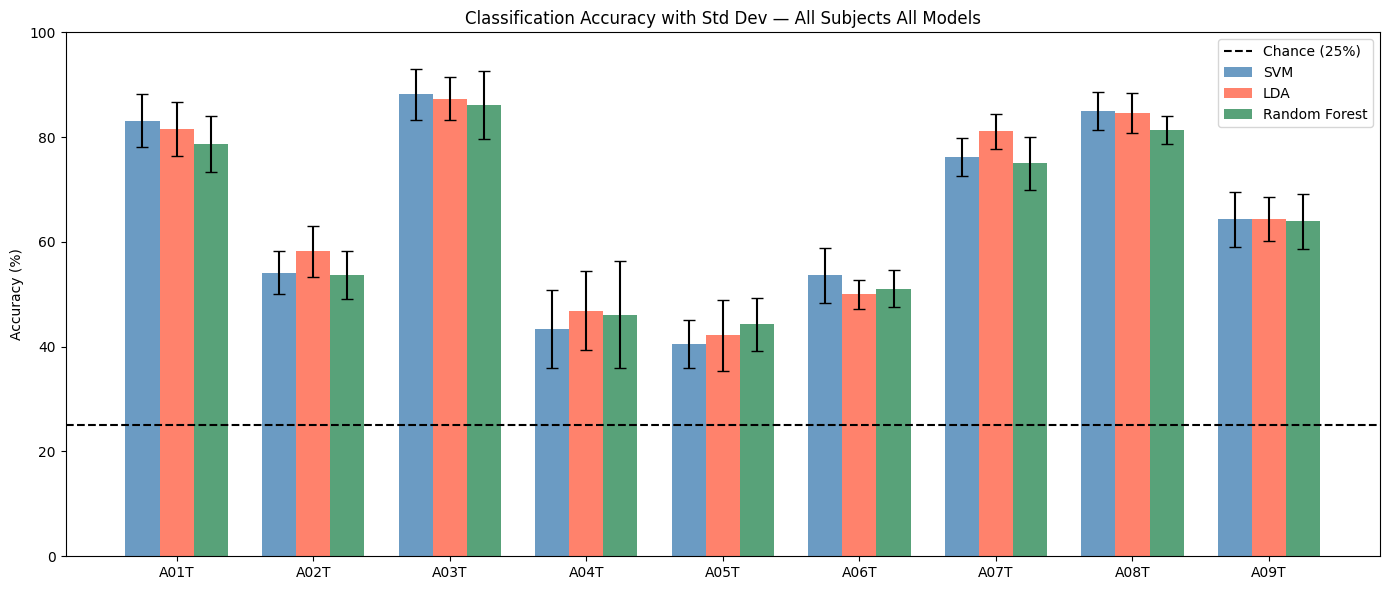

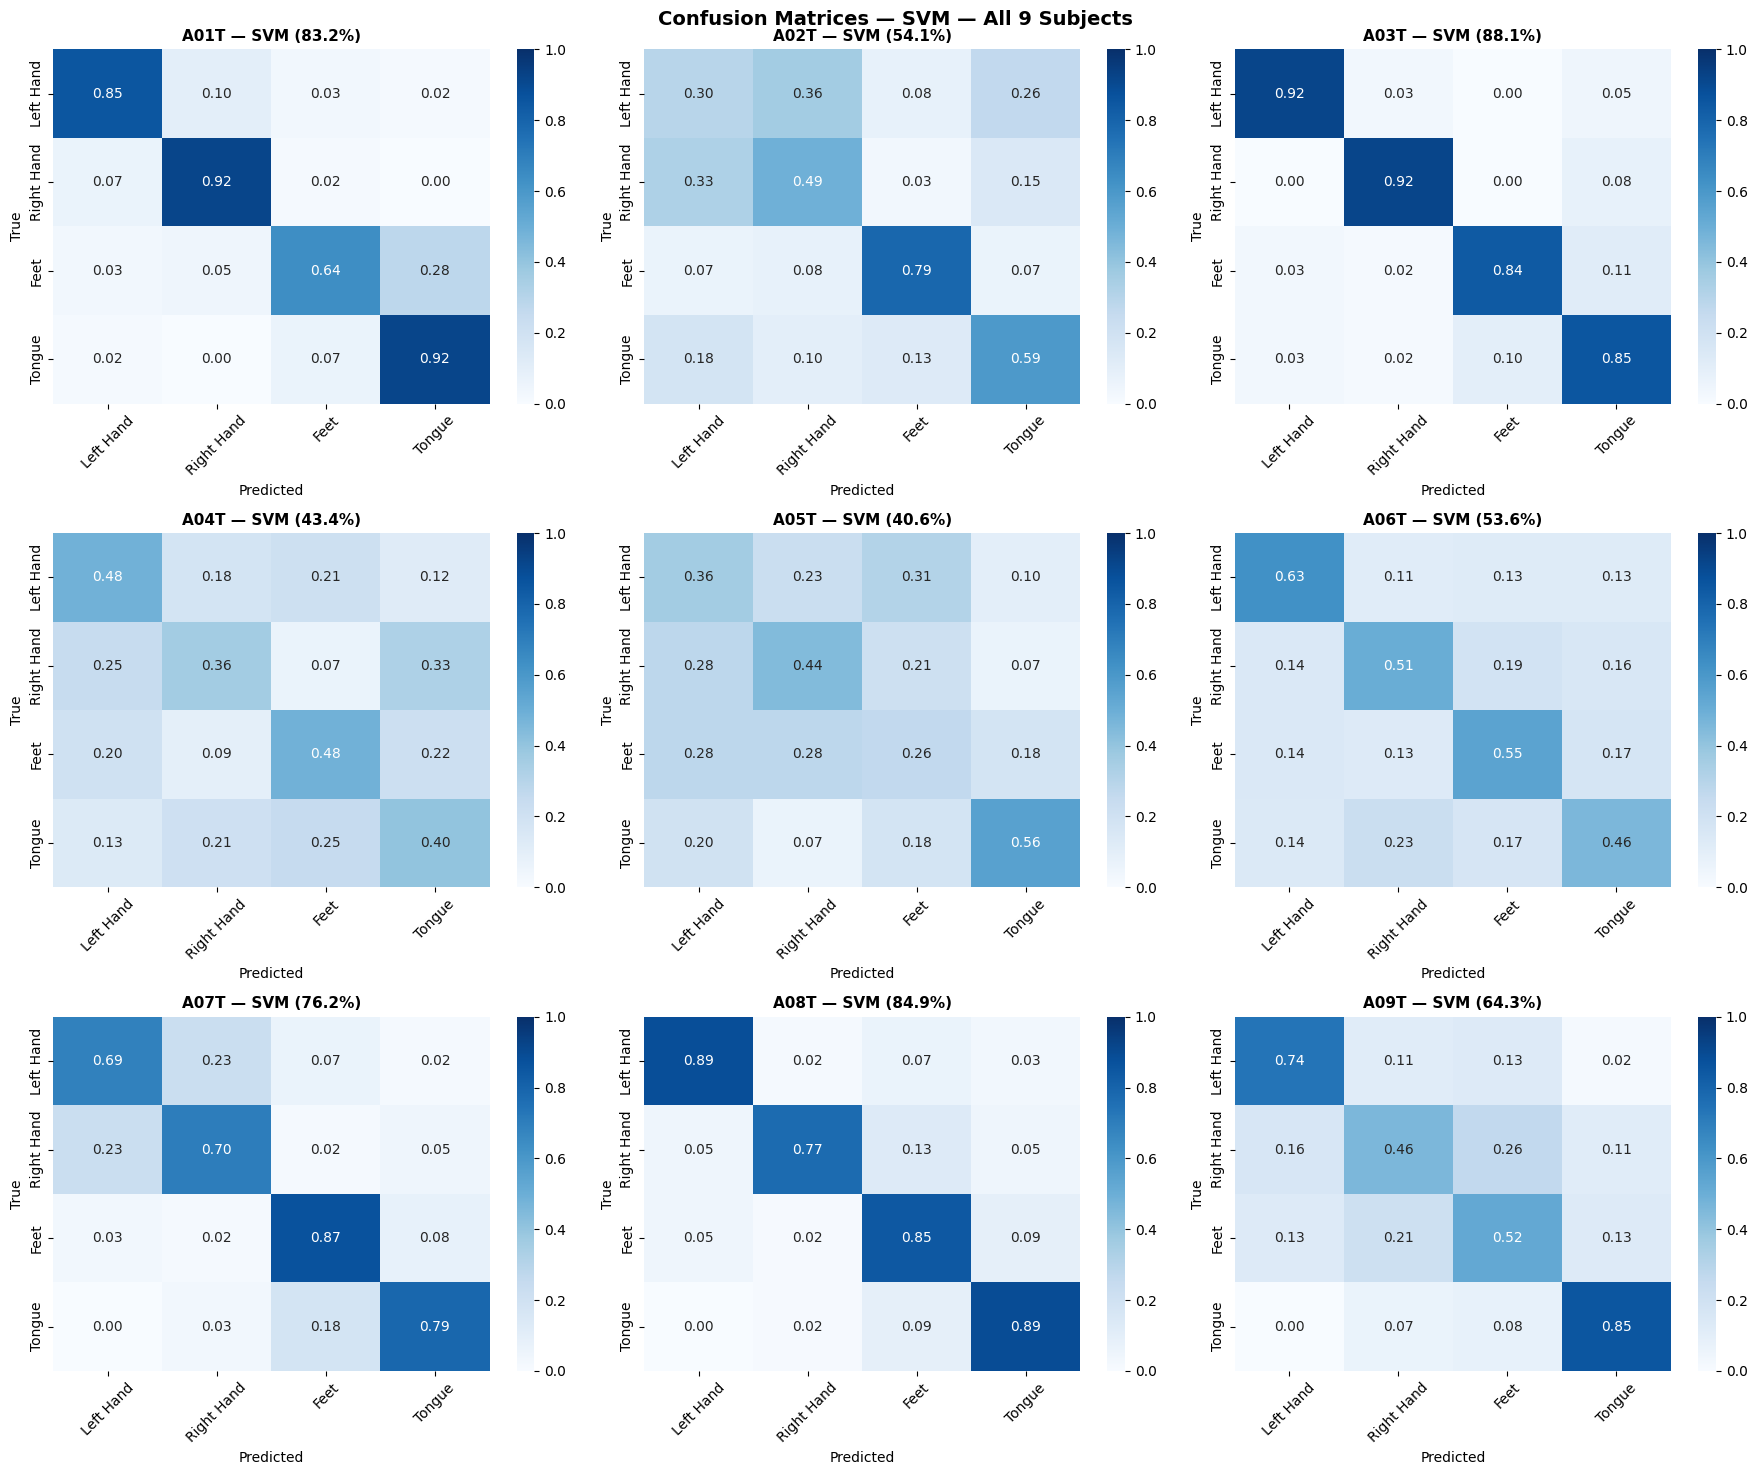

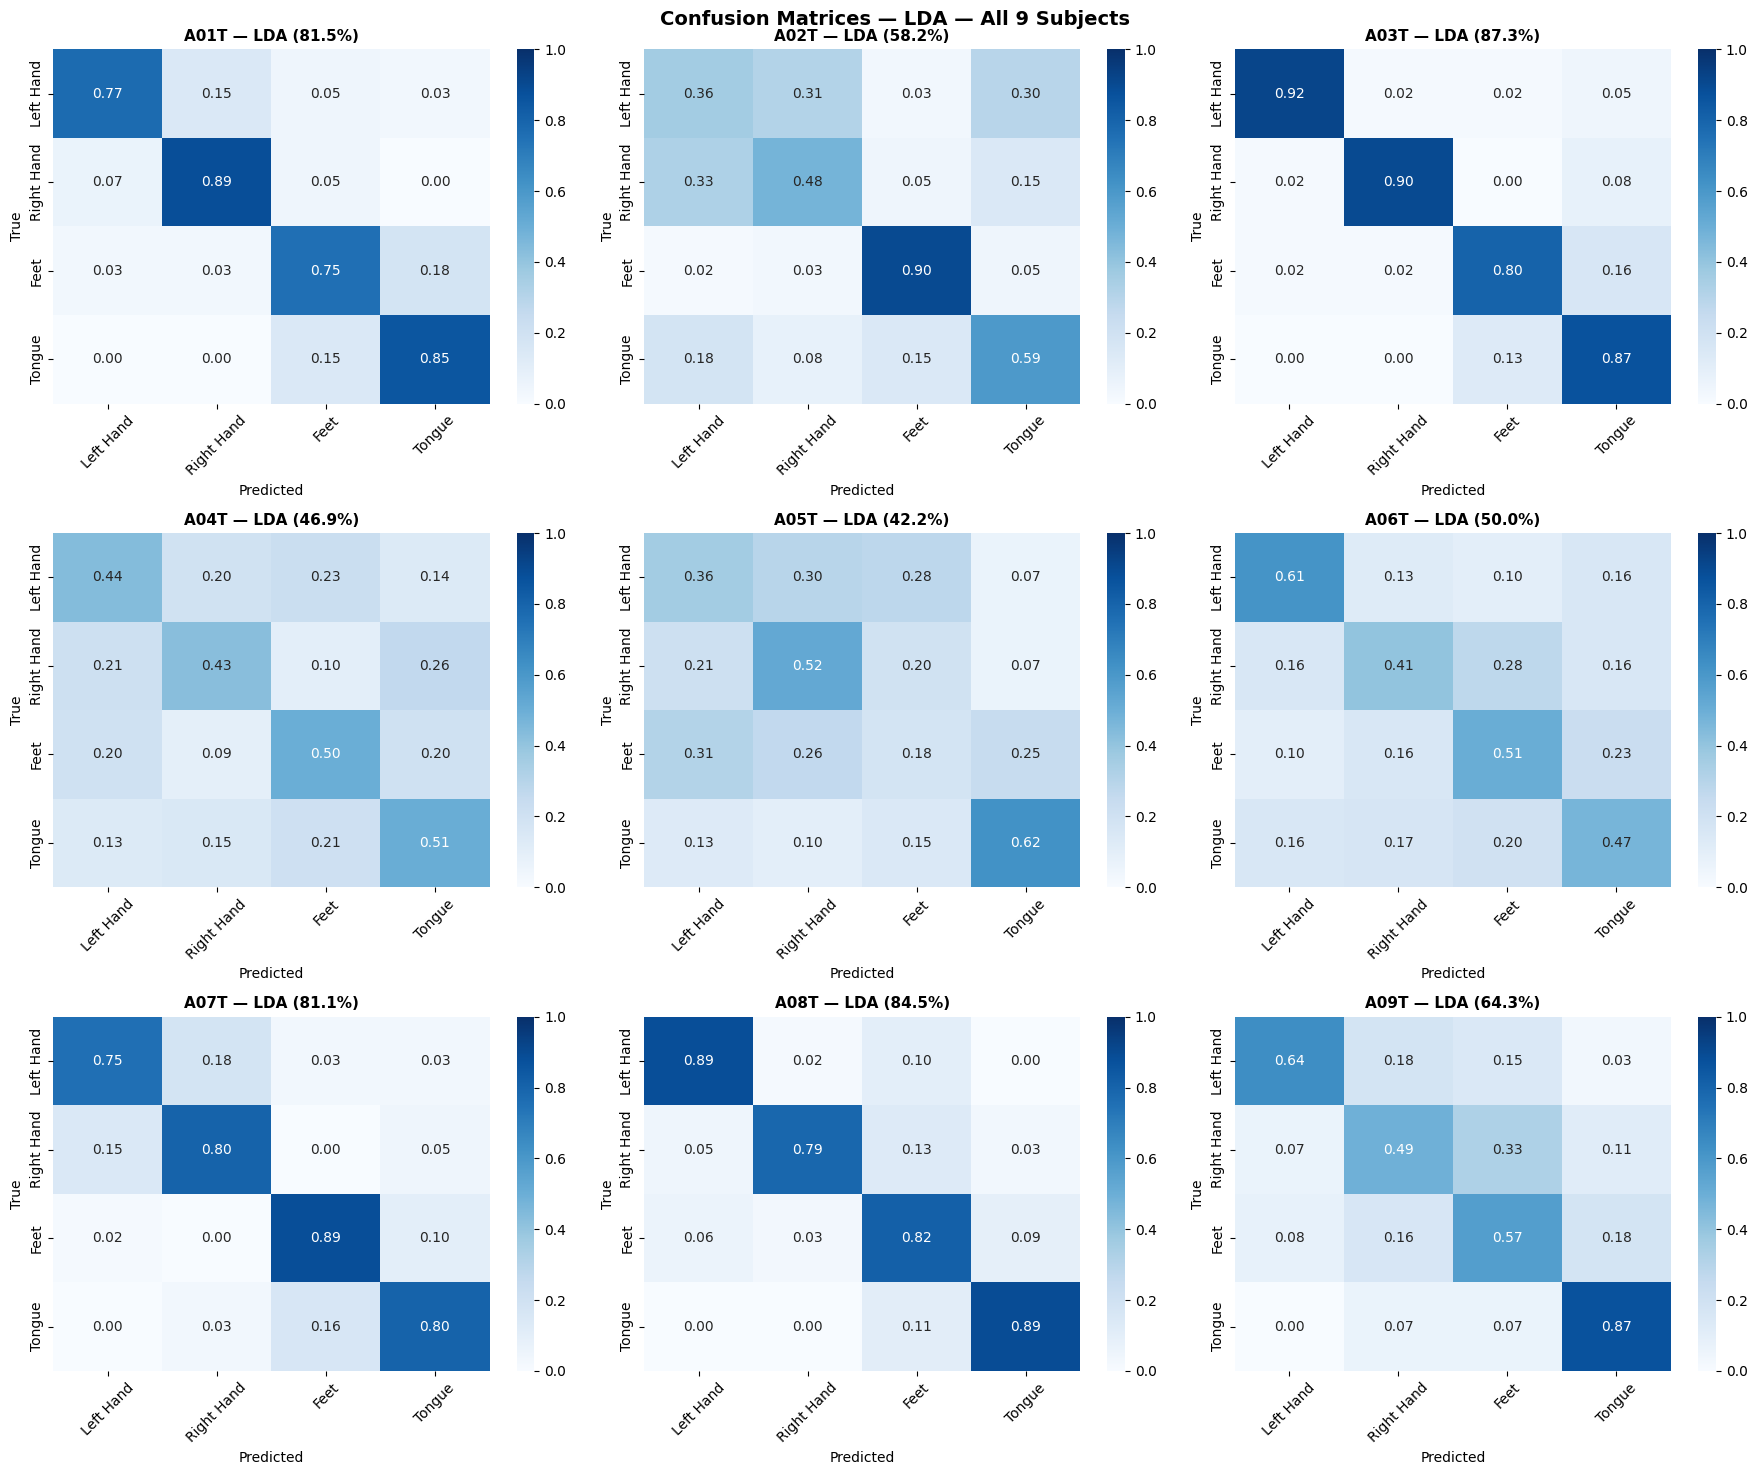

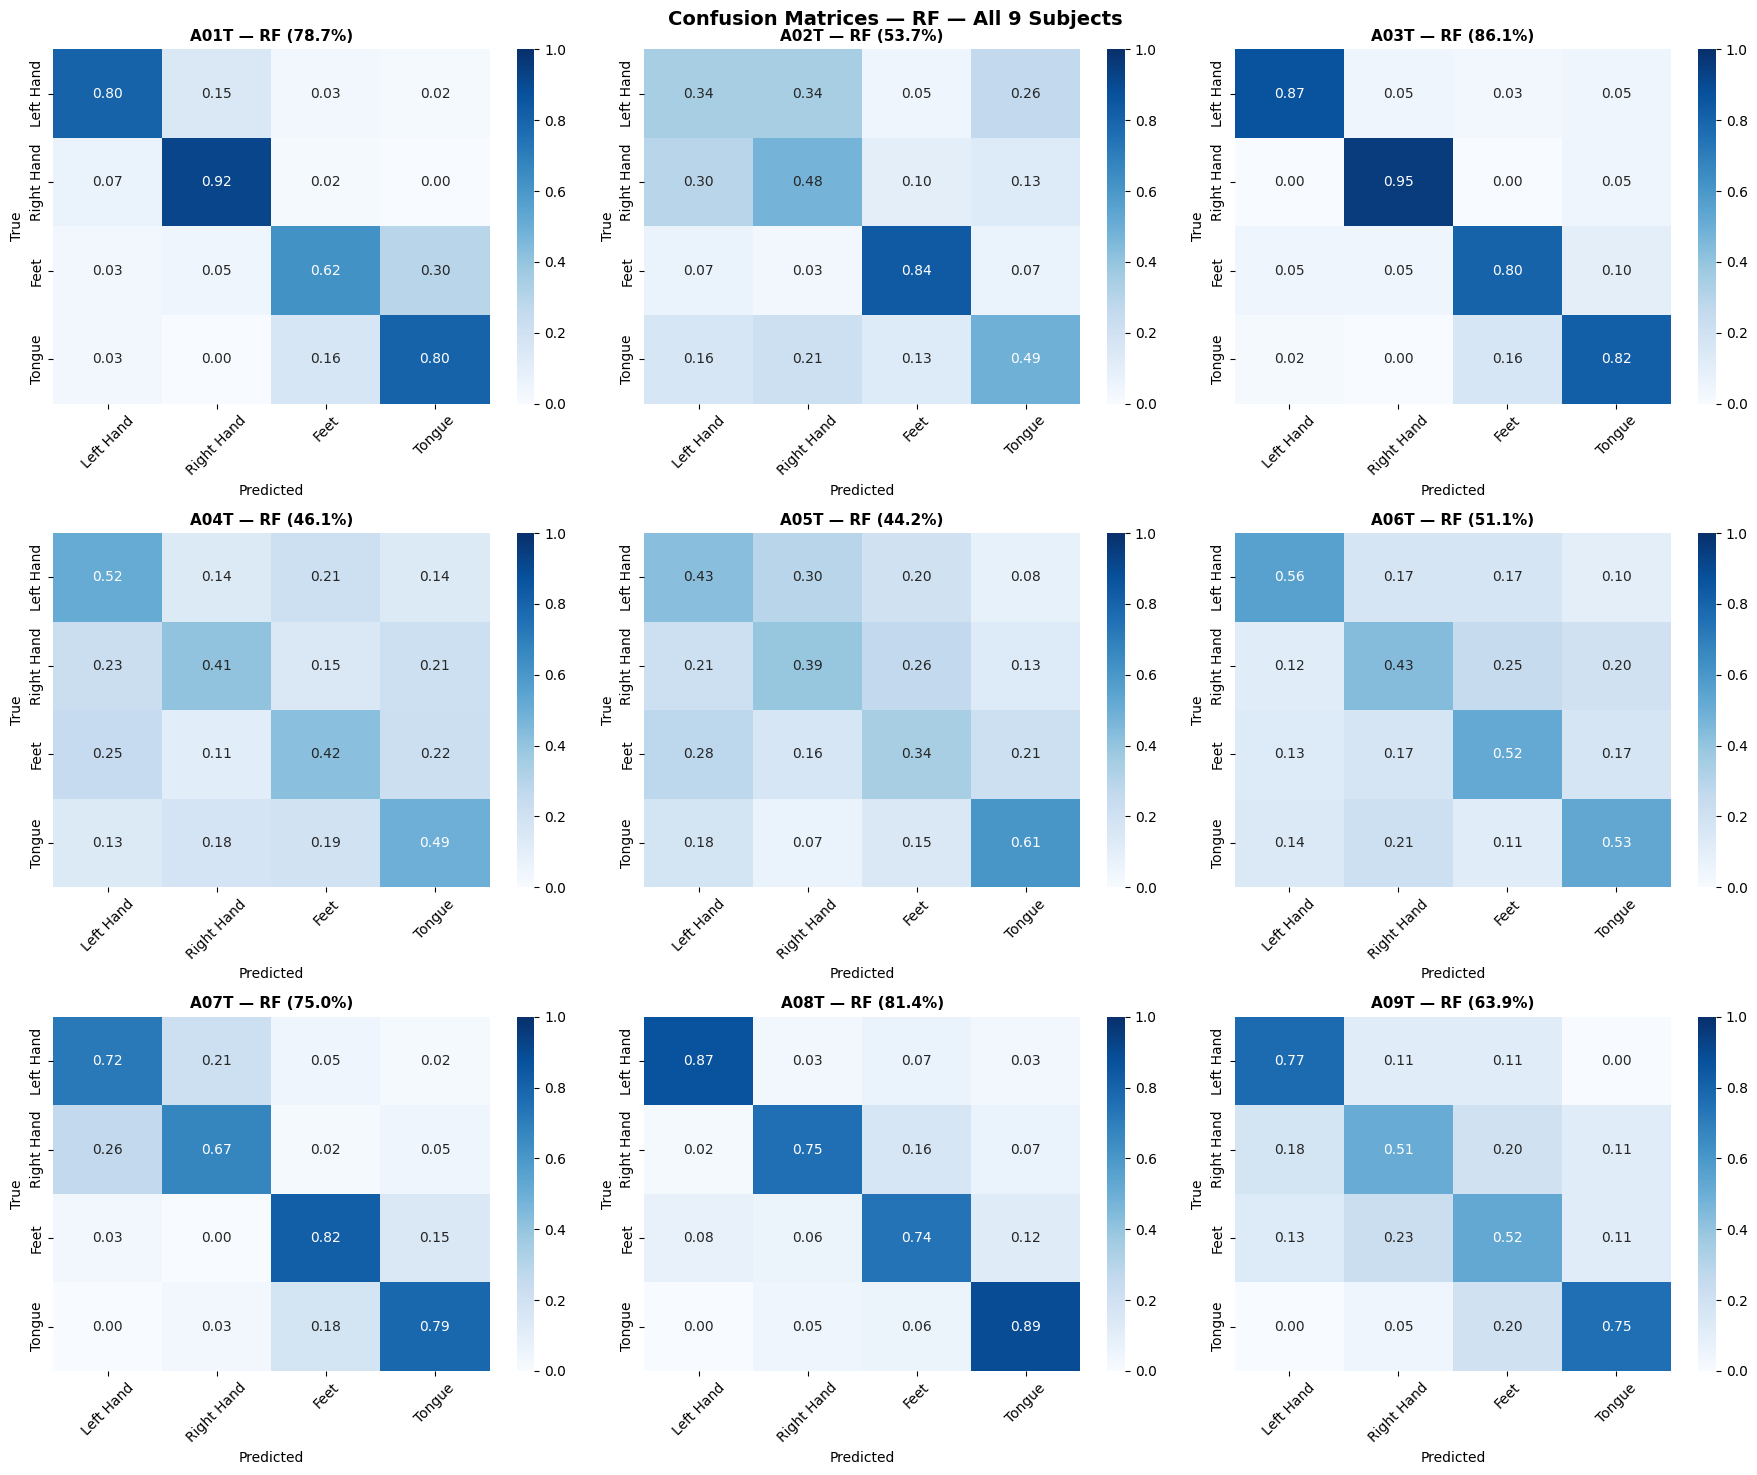

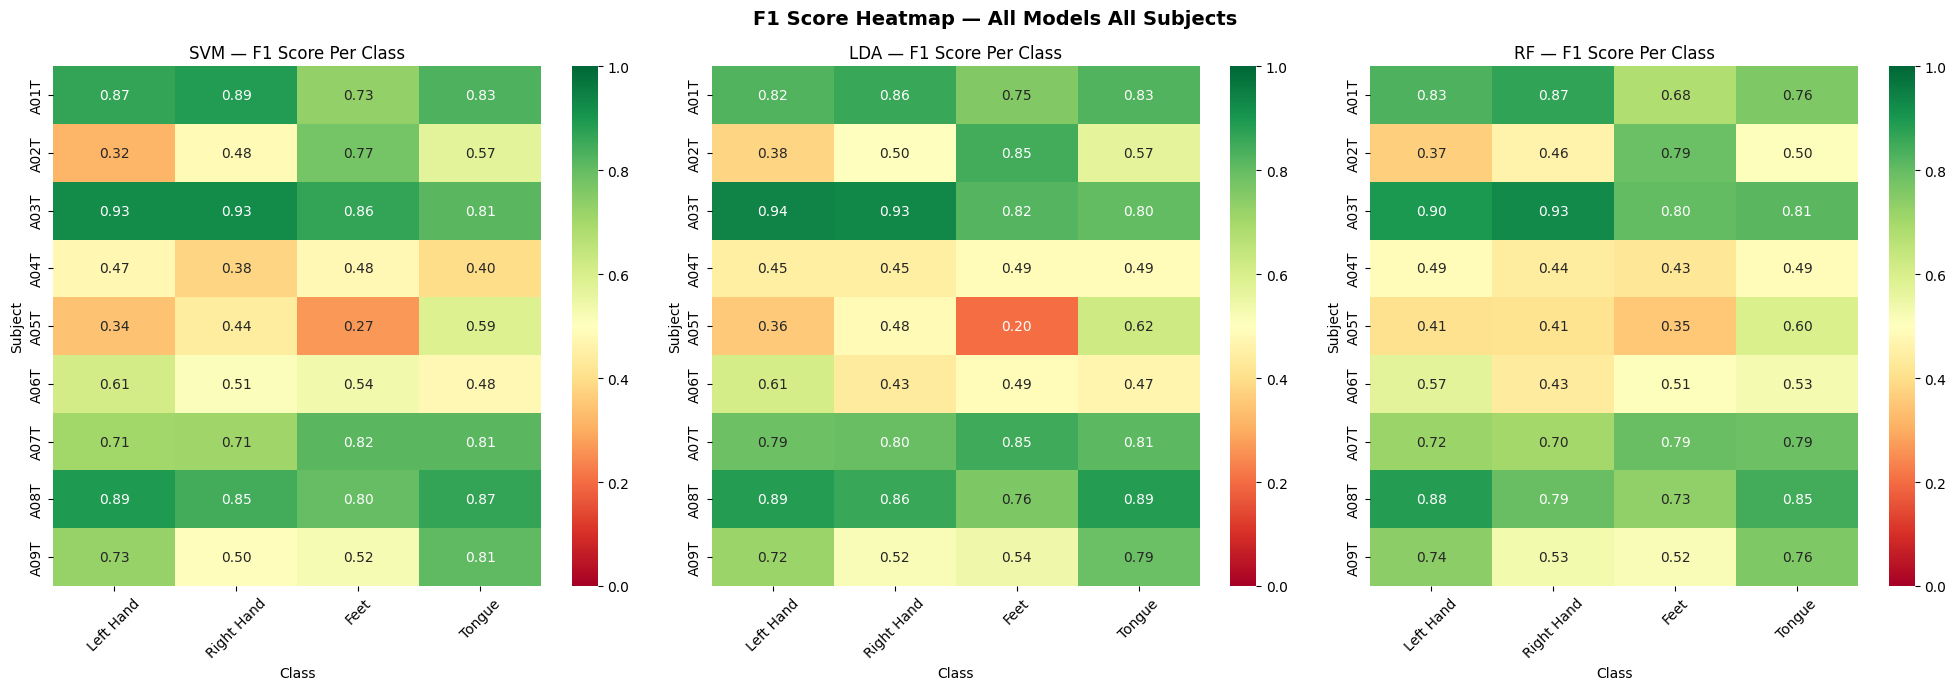

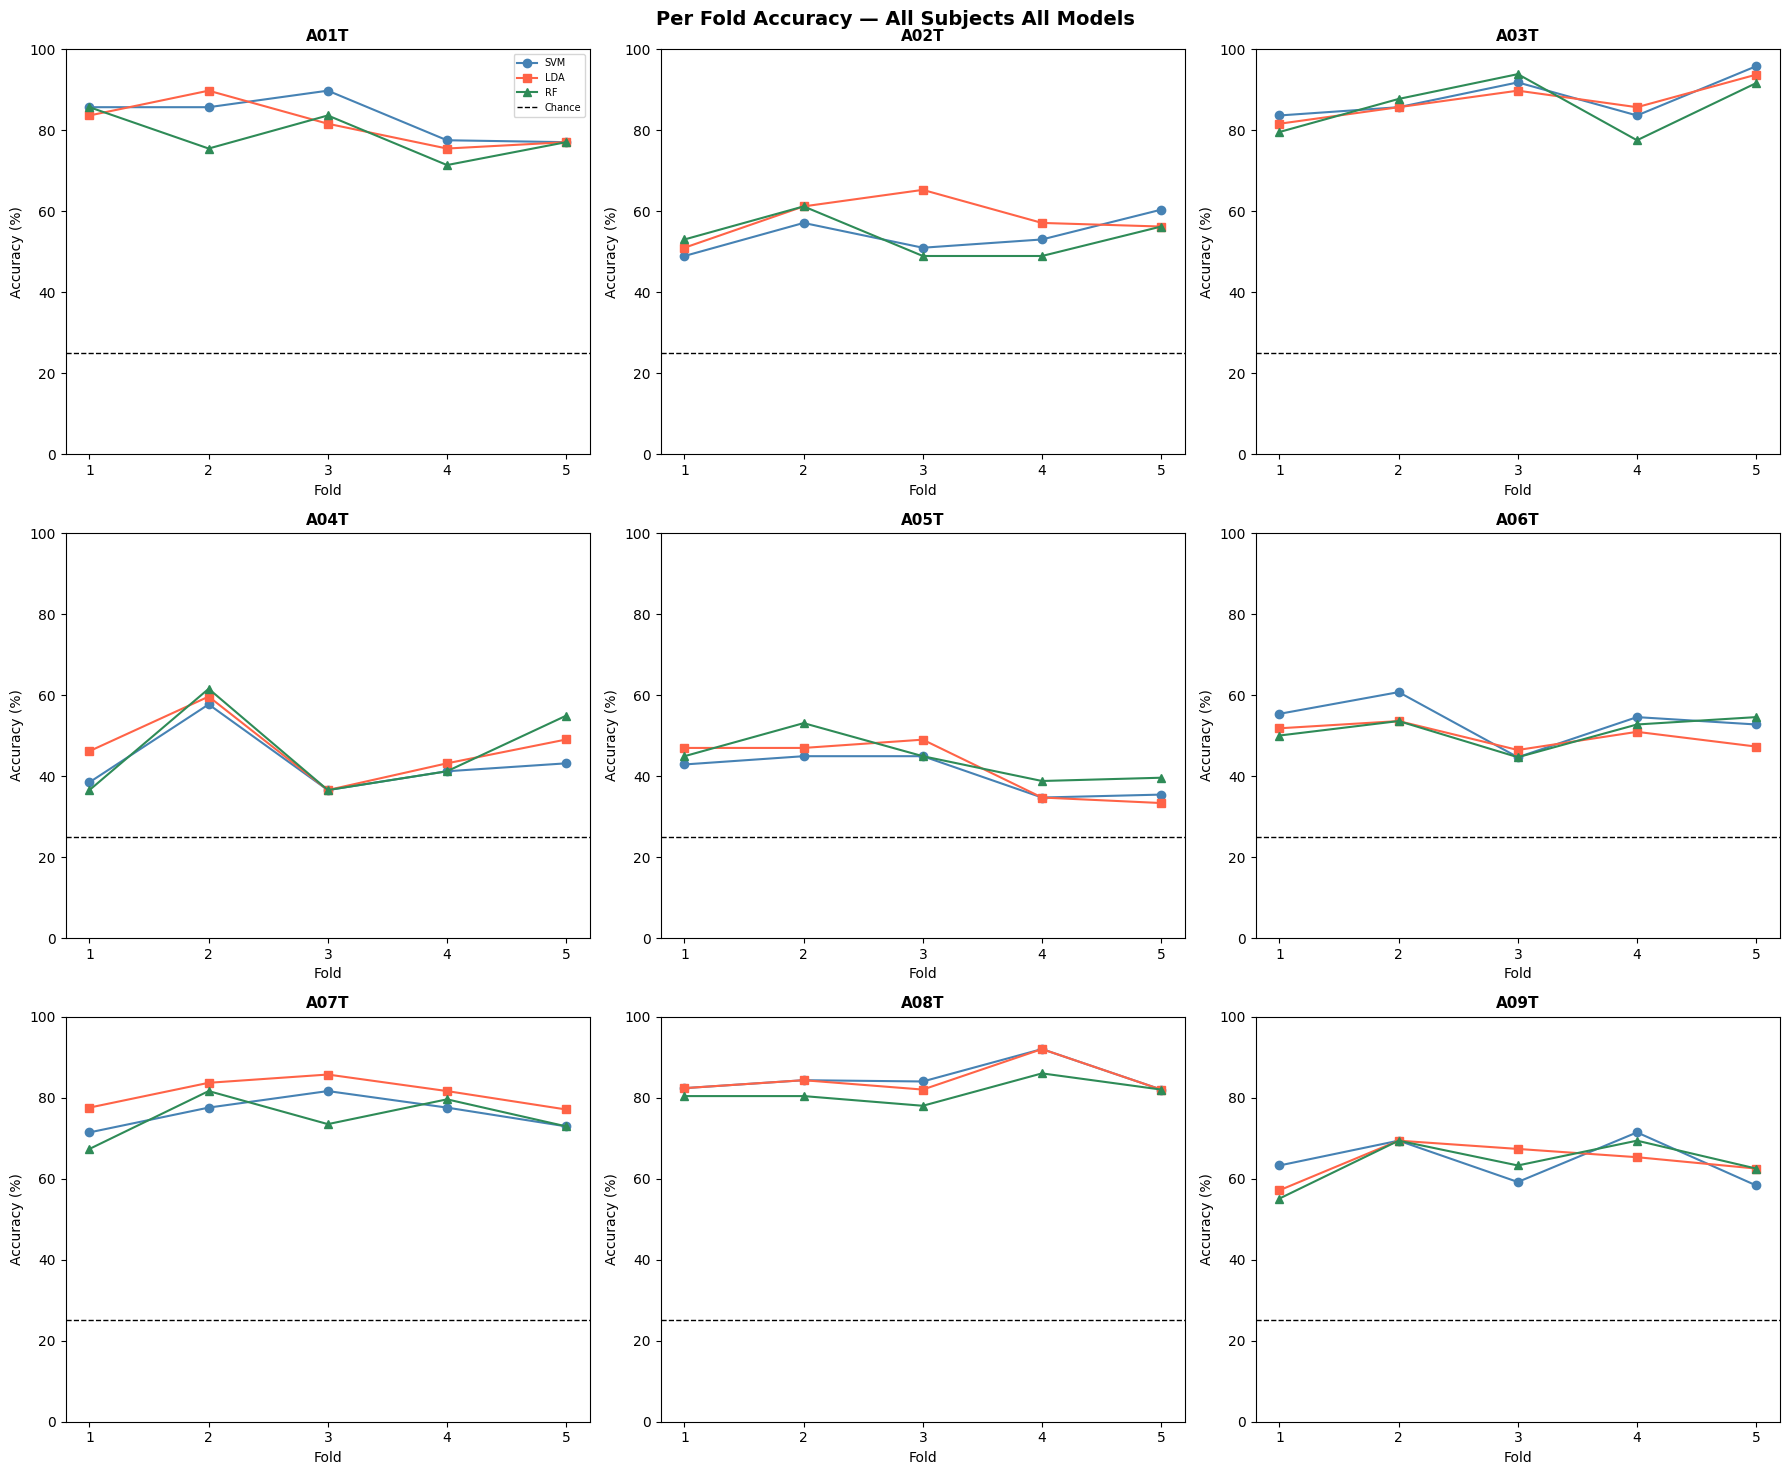

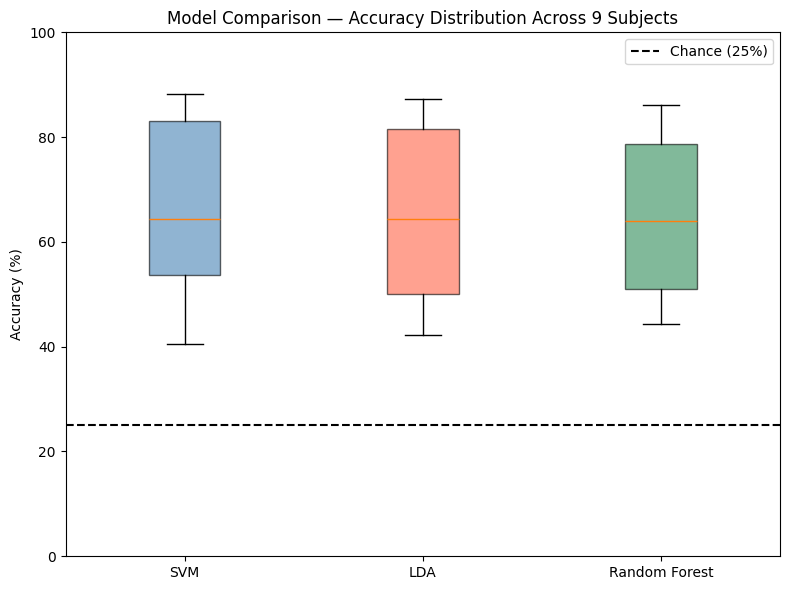

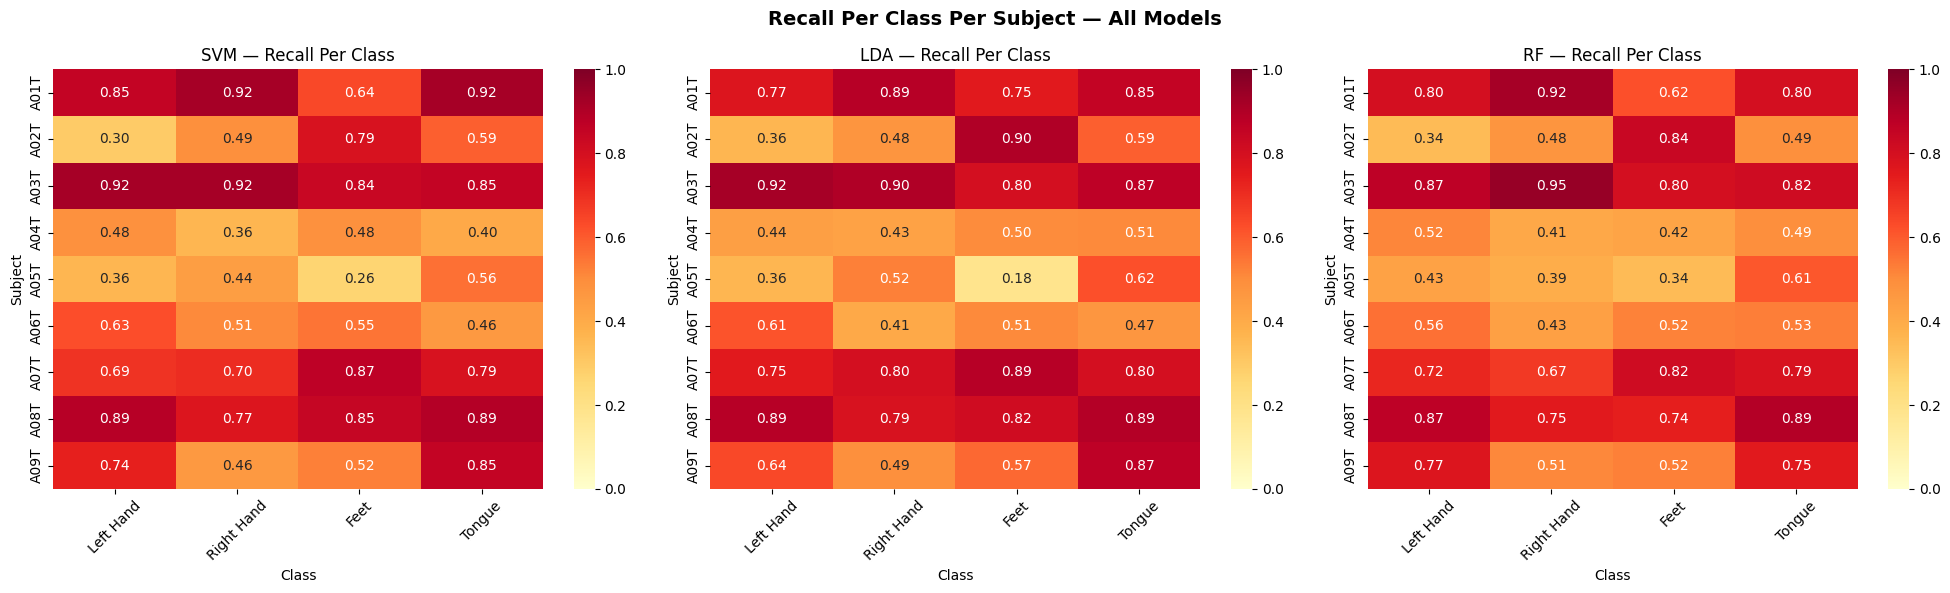

Best subject: A03T — 88.1%


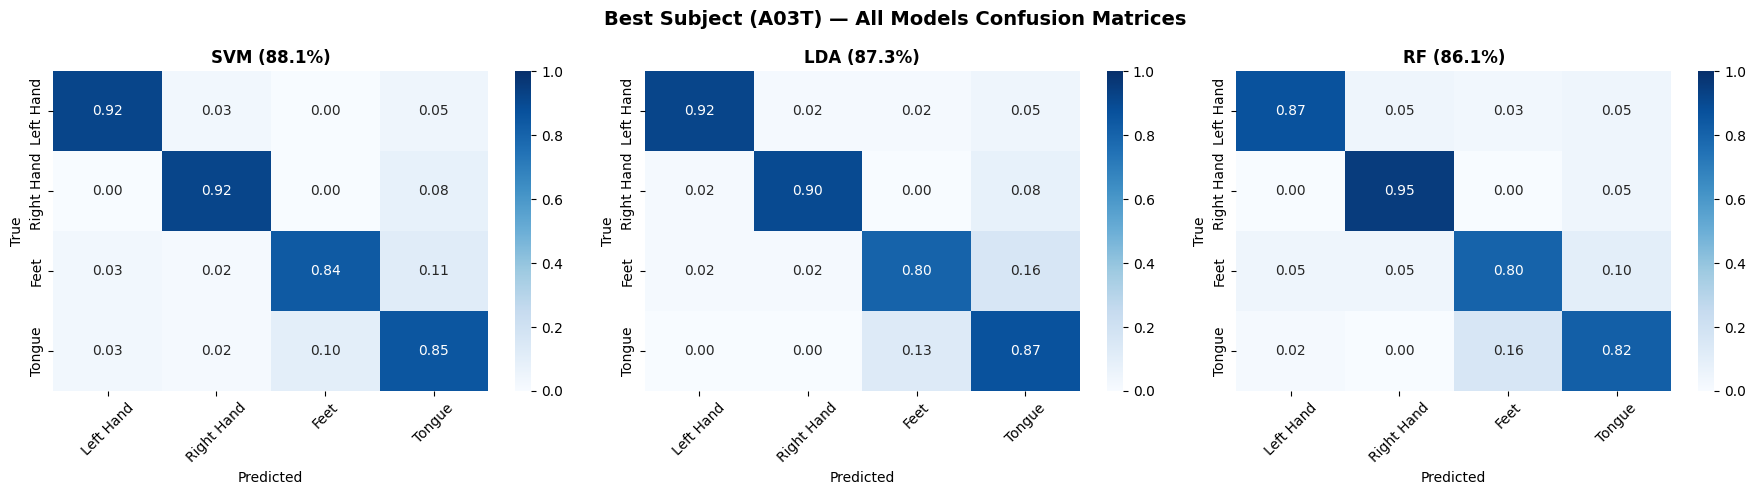

All training visualizations saved.


In [7]:
# Generate all visualizations
run_all_visualizations(all_results, subjects, figures_path=FIGURES_PATH)